# Prueba del cubo temporal

Variables diarias desde diciembre de 2018 como contexto y periodo histórico de 2019-2023.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr

plt.style.use("default")
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})

PROJECT_DIR = Path(r"C:/Users/alfon/PycharmProjects/Sistema-deteccion-incendios")
TIME_PATH = PROJECT_DIR / "data/processed/time_2018_2023.nc"
time_cube = xr.open_dataset(TIME_PATH)
display(time_cube)

<xarray.Dataset> Size: 59kB
Dimensions:          (time: 1857)
Coordinates:
  * time             (time) datetime64[ns] 15kB 2018-12-01 ... 2023-12-31
Data variables:
    year             (time) int16 4kB ...
    month            (time) int8 2kB ...
    iso_week         (time) int8 2kB ...
    day_of_year      (time) int16 4kB ...
    day_of_week      (time) int8 2kB ...
    is_weekend       (time) uint8 2kB ...
    day_of_year_sin  (time) float32 7kB ...
    day_of_year_cos  (time) float32 7kB ...
    month_sin        (time) float32 7kB ...
    month_cos        (time) float32 7kB ...
Attributes:
    title:                Daily temporal variables
    description:          Calendar predictors with December 2018 context for ...
    module:               time
    temporal_resolution:  1 day
    context_period:       2018-12-01 to 2018-12-31
    prediction_period:    2019-01-01 to 2023-12-31

In [2]:
print(f"Inicio: {time_cube.time.min().values}")
print(f"Fin: {time_cube.time.max().values}")
print(f"Días: {len(time_cube.time):,}")
display(time_cube.to_dataframe().describe())

Inicio: 2018-12-01T00:00:00.000000000
Fin: 2023-12-31T00:00:00.000000000
Días: 1,857


,year,month,iso_week,day_of_year,day_of_week,is_weekend,day_of_year_sin,day_of_year_cos,month_sin,month_cos
count,1857.000000,1857.000000,1857.000000,1857.000000,1857.000000,1857.000000,1857.000000,1857.000000,1.857000e+03,1.857000e+03
mean,2020.949381,6.614970,26.984922,185.886376,3.002693,0.286484,-0.004276,0.015798,-4.822012e-03,1.463105e-02
std,1.454267,3.491809,15.247979,106.740014,2.001210,0.452240,0.702444,0.711929,7.000065e-01,7.143475e-01
min,2018.000000,1.000000,1.000000,1.000000,0.000000,0.000000,-0.999999,-0.999979,-1.000000e+00,-1.000000e+00
25%,2020.000000,4.000000,14.000000,93.000000,1.000000,0.000000,-0.702148,-0.698310,-5.000000e-01,-5.000000e-01
50%,2021.000000,7.000000,27.000000,186.000000,3.000000,0.000000,-0.023651,0.022576,-2.449294e-16,6.123234e-17
75%,2022.000000,10.000000,40.000000,279.000000,5.000000,1.000000,0.699079,0.735762,5.000000e-01,8.660254e-01
max,2023.000000,12.000000,53.000000,366.000000,6.000000,1.000000,0.999986,0.999991,1.000000e+00,1.000000e+00


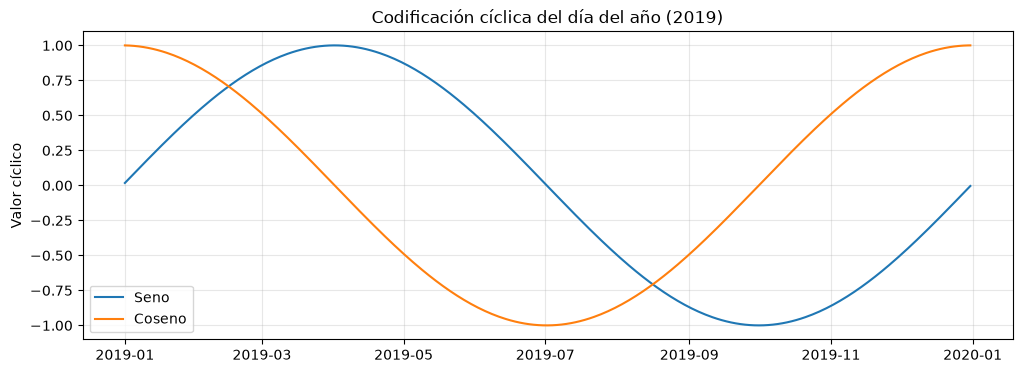

In [3]:
first_year = time_cube.sel(time=slice("2019-01-01", "2019-12-31"))
fig, ax = plt.subplots(figsize=(12, 4), facecolor="white")
ax.plot(first_year.time, first_year.day_of_year_sin, label="Seno")
ax.plot(first_year.time, first_year.day_of_year_cos, label="Coseno")
ax.set_title("Codificación cíclica del día del año (2019)")
ax.set_ylabel("Valor cíclico")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## Validación visual del contrato final

Esta celda comprueba que la variable existe en el cubo final y la representa sobre la máscara de Galicia con fondo blanco.

In [4]:
import xarray as xr
from src.config import DATACUBE_PATH

with xr.open_dataset(DATACUBE_PATH) as cube:
    assert not {"year", "month", "iso_week", "day_of_year", "day_of_week", "is_weekend"} & set(cube.data_vars)
    display(cube.time.to_dataframe().head())
print("✓ El calendario se deriva de la coordenada time; no se almacena como predictor.")

AssertionError: 